# Customer Segmentation using RFM Analysis

## SQL + Python | Business Analytics Project

### Project Overview

This project applies RFM (Recency, Frequency, Monetary) analysis to segment customers based on their purchasing behavior. The objective is to identify valuable customer groups that can support targeted marketing campaigns, improve customer retention, and increase business revenue.

The project combines SQL for data preparation and Python for customer segmentation, exploratory data analysis, visualization, and business recommendations.

## Executive Summary

- Segmented **5,878 customers** from the Online Retail II dataset using RFM analysis.
- Identified **Champions** and **Loyal Customers** as the highest-revenue segments, despite being a smaller share of the customer base.
- Flagged a meaningful **At Risk / Lost Customers** group for win-back campaigns.
- Recommended segment-specific marketing actions to improve retention and revenue without increasing overall marketing spend.

# Business Problem

Many companies spend significant marketing budgets treating every customer the same. However, customers have different purchasing behaviors and lifetime values.

Using RFM analysis, customers can be grouped into meaningful business segments such as Champions, Loyal Customers, At Risk, and Lost Customers.

These insights enable businesses to:

- Improve customer retention
- Reduce customer churn
- Optimize marketing campaigns
- Increase customer lifetime value
- Allocate marketing budgets efficiently

# Dataset

Source:
Online Retail II Dataset (UCI Machine Learning Repository)

The dataset contains historical retail transactions from a UK-based online retailer.

Analysis Period:
December 2009 - December 2011

After SQL preprocessing:

- Removed cancelled invoices
- Removed invalid quantities
- Removed invalid prices
- Removed unknown customers

The cleaned customer-level dataset was exported from SQL and analyzed in Python.

# Import Libraries

In [1]:
# If running in Google Colab, uncomment the two lines below to upload rfm_base.csv manually.
# from google.colab import files
# uploaded = files.upload()


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


# Load Dataset

In [3]:
rfm = pd.read_csv('../data/rfm_base.csv')


# Dataset Overview

In [4]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,18102,1,145,608821.65
1,14646,2,151,528602.52
2,14156,10,156,313946.37
3,14911,2,398,295972.63
4,17450,9,51,246973.09


In [5]:
rfm.shape

(5878, 4)

In [6]:
rfm.describe( )

,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.866791,6.289384,3018.616734
std,1715.572666,209.353961,13.009406,14737.731038
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,398.000000,608821.650000


In [7]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  5878 non-null   int64  
 1   Recency     5878 non-null   int64  
 2   Frequency   5878 non-null   int64  
 3   Monetary    5878 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 183.8 KB


# Customer Statistics

In [8]:
print(f"Total Customers : {len(rfm):,}")

print(f"Average Recency : {rfm['Recency'].mean():.2f} days")

print(f"Average Frequency : {rfm['Frequency'].mean():.2f}")

print(f"Average Monetary : £{rfm['Monetary'].mean():,.2f}")


Total Customers : 5,878
Average Recency : 201.87 days
Average Frequency : 6.29
Average Monetary : £3,018.62


#Distribution Histograms

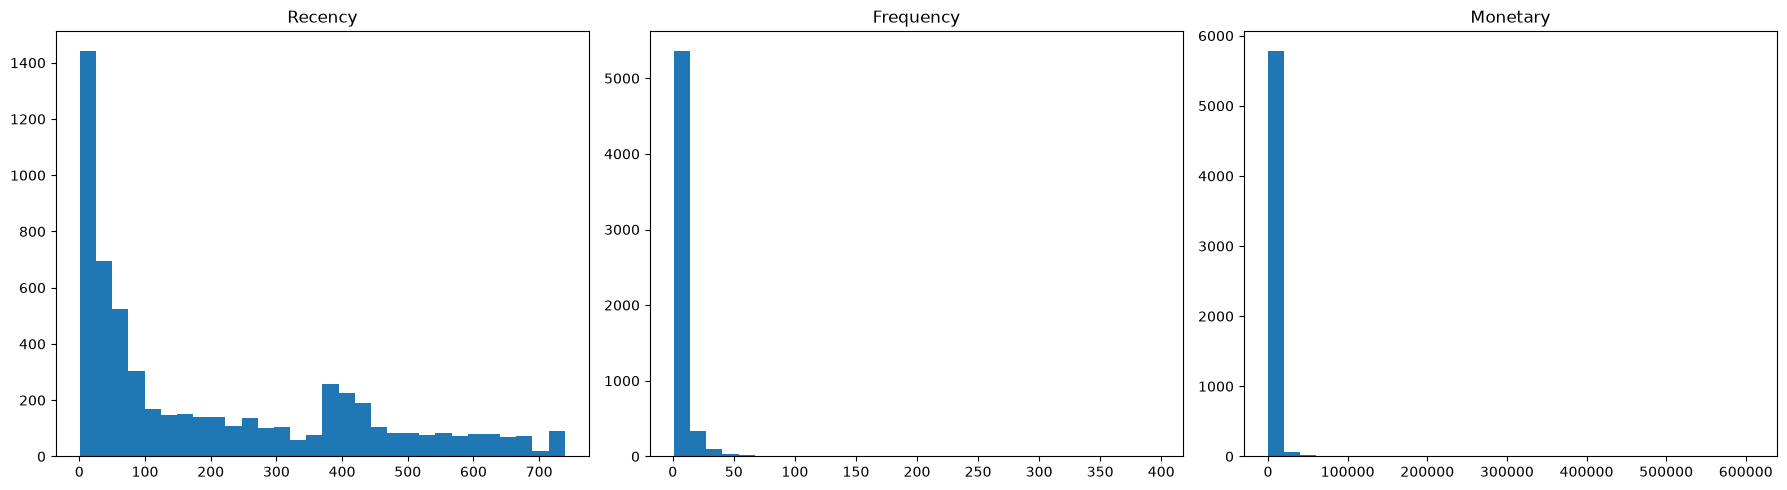

In [9]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

columns = ['Recency','Frequency','Monetary']

for ax,col in zip(axes,columns):
    ax.hist(rfm[col], bins=30)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# RFM Scoring

Each customer receives a score between 1 and 4 for Recency, Frequency, and Monetary.

Recency:
Lower recency indicates a more recent purchase, therefore lower values receive higher scores.

Frequency:
Customers with more purchases receive higher scores.

Monetary:
Customers with higher total spending receive higher scores.

In [10]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [11]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,18102,1,145,608821.65,4,4,4
1,14646,2,151,528602.52,4,4,4
2,14156,10,156,313946.37,4,4,4
3,14911,2,398,295972.63,4,4,4
4,17450,9,51,246973.09,4,4,4


# Combining RFM Scores

The individual R, F, and M scores are combined into a single three-digit RFM score that summarizes each customer's overall behavior.

In [12]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)


In [13]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,18102,1,145,608821.65,4,4,4,444
1,14646,2,151,528602.52,4,4,4,444
2,14156,10,156,313946.37,4,4,4,444
3,14911,2,398,295972.63,4,4,4,444
4,17450,9,51,246973.09,4,4,4,444


In [14]:
 rfm['RFM_Score'].value_counts().head(20)

RFM_Score
444    645
111    536
344    340
211    242
121    197
233    196
333    191
112    181
222    177
433    175
122    170
232    166
311    140
323    134
244    129
223    129
432    128
322    120
332    118
221    115
Name: count, dtype: int64

# Customer Segmentation

Customers are classified into business-friendly segments using their RFM scores.

Each segment represents a different marketing strategy.

In [15]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    # Champions: recent, frequent, high spend
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'

    # Loyal Customers: frequent and decent spend, but not always top recent
    elif f >= 3 and m >= 2:
        return 'Loyal Customers'

    # Big Spenders: spend a lot but may not buy often
    elif m >= 4 and f <= 2:
        return 'Big Spenders'

    # Potential Loyalists: recent customers with some promise
    elif r >= 3 and f >= 2:
        return 'Potential Loyalists'

    # At Risk: used to buy / spend but haven’t purchased recently
    elif r <= 2 and (f >= 3 or m >= 3):
        return 'At Risk'

    # Lost Customers: low recency, low frequency, low monetary
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customers'

    # Others / average customers
    else:
        return 'Others'

In [16]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [17]:
rfm['Segment'].value_counts()

Segment
Champions              1752
Lost Customers         1708
Loyal Customers        1113
Potential Loyalists     560
Others                  347
At Risk                 326
Big Spenders             72
Name: count, dtype: int64

# Segment Performance Analysis

After assigning customers to business segments, the next step is to evaluate the characteristics of each segment.

For every customer segment, the following metrics are calculated:

- **Customer Count** - Number of customers in the segment.
- **Average Recency** - Average number of days since the last purchase.
- **Average Frequency** - Average number of purchases made by customers in the segment.
- **Average Monetary Value** - Average total amount spent by customers.

This summary validates whether the segmentation logic correctly reflects different customer purchasing behaviors and helps identify appropriate marketing strategies for each segment.

In [18]:
segment_summary = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'CustomerID': 'Customer_Count'})

segment_summary.sort_values('Monetary', ascending=False).round(2)

,Customer_Count,Recency,Frequency,Monetary
Segment,,,,
Big Spenders,72,244.33,2.36,8022.48
Champions,1752,29.43,14.49,7623.90
Loyal Customers,1113,220.64,6.01,2089.20
At Risk,326,345.69,2.44,1154.19
Potential Loyalists,560,38.49,2.34,773.95
Others,347,46.02,1.00,365.02
Lost Customers,1708,422.49,1.33,320.33


In [19]:
business_summary = rfm.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum'),
    Median_Monetary=('Monetary', 'median')
).round(2)

business_summary.sort_values('Total_Revenue', ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Median_Monetary
Segment,,,,,,
Champions,1752,29.43,14.49,7623.90,13357070.40,3256.68
Loyal Customers,1113,220.64,6.01,2089.20,2325277.31,1006.98
Big Spenders,72,244.33,2.36,8022.48,577618.67,3409.66
Lost Customers,1708,422.49,1.33,320.33,547124.39,280.06
Potential Loyalists,560,38.49,2.34,773.95,433410.27,721.82
At Risk,326,345.69,2.44,1154.19,376264.67,1126.72
Others,347,46.02,1.00,365.02,126663.45,291.88


# Visualization 1 - Customer Distribution

## Business Question

How are customers distributed across different business segments?

## Why is this important?

Understanding the size of each customer segment helps businesses prioritize marketing efforts and allocate resources effectively.

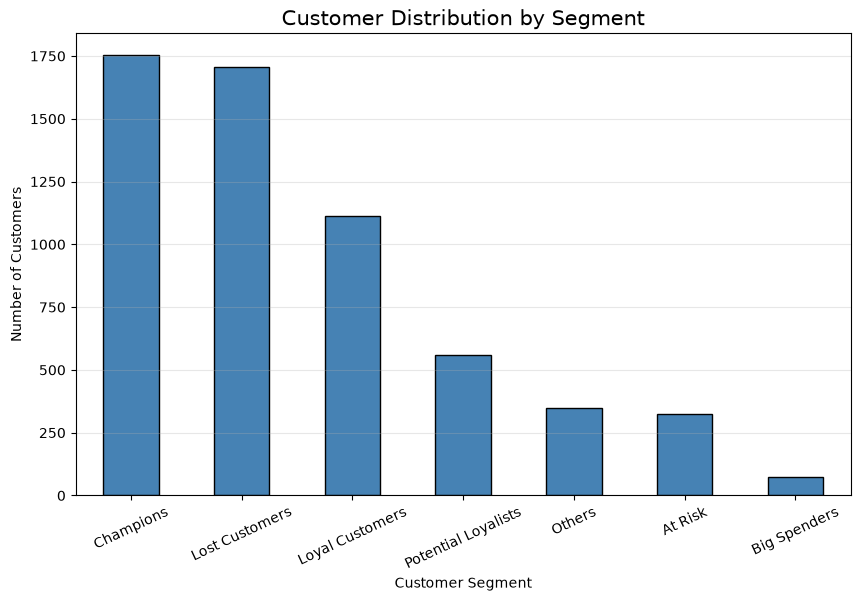

In [20]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10,6))

segment_counts.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Customer Distribution by Segment', fontsize=15)

plt.xlabel('Customer Segment')

plt.ylabel('Number of Customers')

plt.xticks(rotation=25)

plt.grid(axis='y', alpha=0.3)

plt.show()

### Key Findings

- Identify the largest customer segments.
- Identify the smallest customer segments.
- Compare active and inactive customers.

### Business Recommendation

Marketing efforts should prioritize high-value customer groups while designing targeted campaigns for inactive customers.

# Visualization 2 - Average Monetary Value

## Business Question

Which customer segments contribute the highest revenue?

## Why is this important?

Businesses should focus retention efforts on customers generating the greatest revenue.

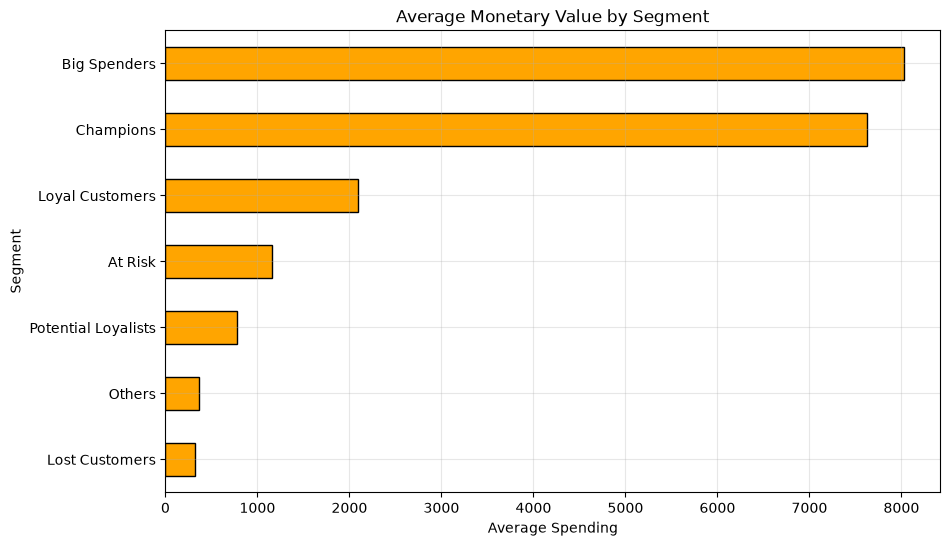

In [21]:
segment_summary['Monetary'].sort_values().plot(
    kind='barh',
    figsize=(10,6),
    color='orange',
    edgecolor='black'
)

plt.title('Average Monetary Value by Segment')

plt.xlabel('Average Spending')

plt.ylabel('Segment')

plt.grid(alpha=.3)

plt.show()

### Key Findings

- Compare spending across customer segments.
- Identify premium customer groups.
- Identify low-value customers.

### Business Recommendation

Provide exclusive offers and premium services to high-spending customers while nurturing medium-value customers to increase future revenue.

# Visualization 3 - Purchase Frequency

## Business Question

Which customer segments purchase most frequently?

## Why is this important?

Purchase frequency reflects customer loyalty and long-term engagement.

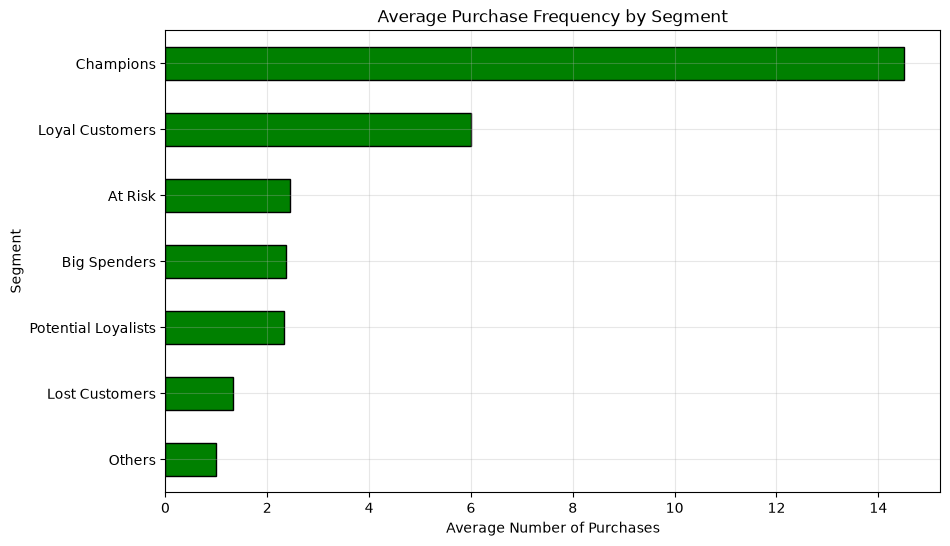

In [22]:
segment_summary['Frequency'].sort_values().plot(
    kind='barh',
    figsize=(10,6),
    color='green',
    edgecolor='black'
)

plt.title('Average Purchase Frequency by Segment')

plt.xlabel('Average Number of Purchases')

plt.grid(alpha=.3)

plt.show()

### Key Findings

- Identify repeat buyers.
- Compare loyal and inactive customers.

### Business Recommendation

Reward frequent customers with loyalty programs and encourage occasional buyers to purchase more often.

# Visualization 4 - Customer Recency

## Business Question

Which customer segments have purchased recently, and which have become inactive?

## Why is this important?

Recency is one of the strongest indicators of future purchasing behavior.

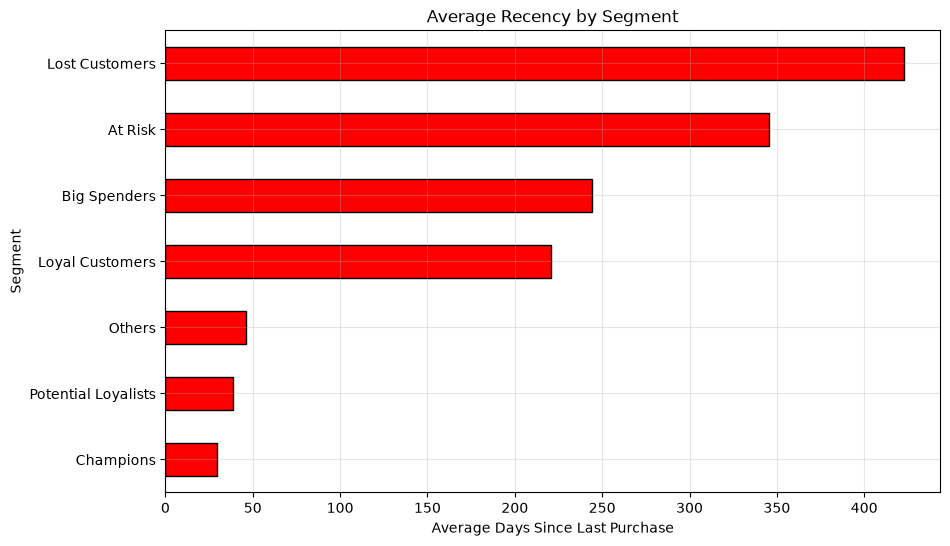

In [23]:
segment_summary['Recency'].sort_values().plot(
    kind='barh',
    figsize=(10,6),
    color='red',
    edgecolor='black'
)

plt.title('Average Recency by Segment')

plt.xlabel('Average Days Since Last Purchase')

plt.grid(alpha=.3)

plt.show()

### Key Findings

- Identify recently active customers.
- Identify customers at risk of churn.

### Business Recommendation

Re-engage inactive customers through personalized campaigns before they are permanently lost.

# Visualization 5 - Segment Distribution

## Business Question

What percentage of the customer base belongs to each segment?

## Why is this important?

Understanding the customer composition helps businesses estimate marketing effort and budget allocation.

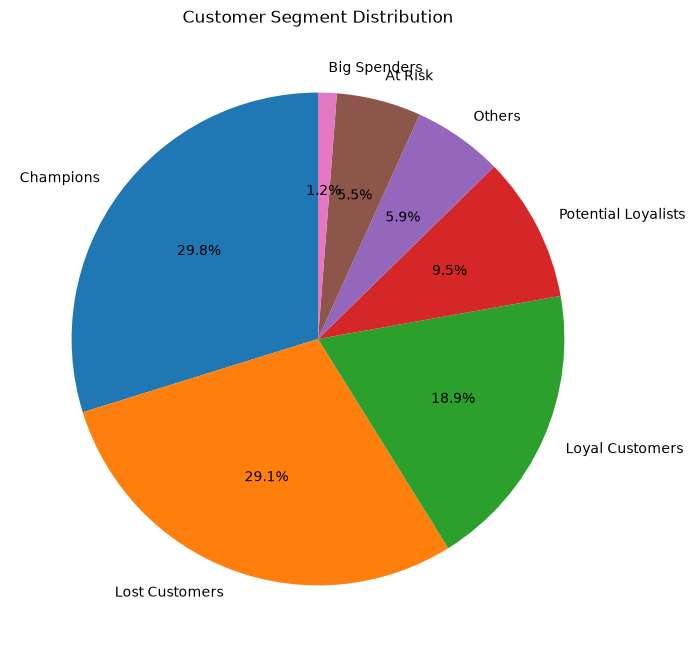

In [24]:
plt.figure(figsize=(8,8))

rfm['Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel('')

plt.title('Customer Segment Distribution')

plt.show()

### Key Findings

- Compare the relative size of each customer segment.

### Business Recommendation

Allocate marketing resources based on the proportion and business value of each segment.

# Visualization 6 - Frequency vs Monetary Analysis

## Business Question

Is there a relationship between purchase frequency and customer spending?

## Why is this important?

Understanding this relationship helps identify premium customers, loyal customers, and unusual purchasing patterns.

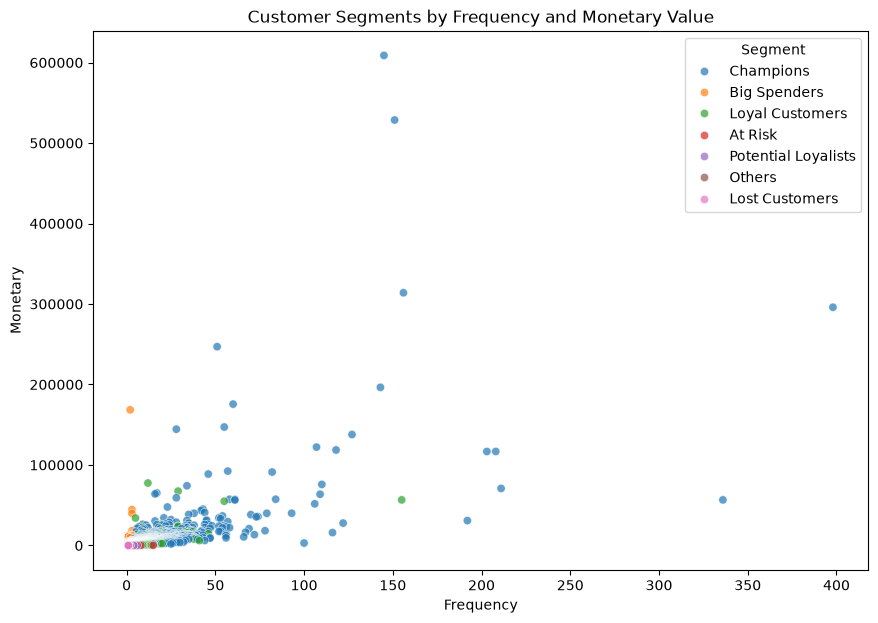

In [25]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    alpha=0.7
)

plt.title('Customer Segments by Frequency and Monetary Value')

plt.show()

### Key Findings

- Observe customer clusters.
- Identify high-value outliers.
- Compare spending behavior across segments.

### Business Recommendation

Develop personalized marketing strategies for customers exhibiting high-value purchasing behavior.

# Visualization 7 - Correlation Analysis

## Business Question

How strongly are Recency, Frequency, and Monetary related?

## Why is this important?

Correlation analysis reveals whether customer behavior metrics influence one another and helps understand purchasing patterns.

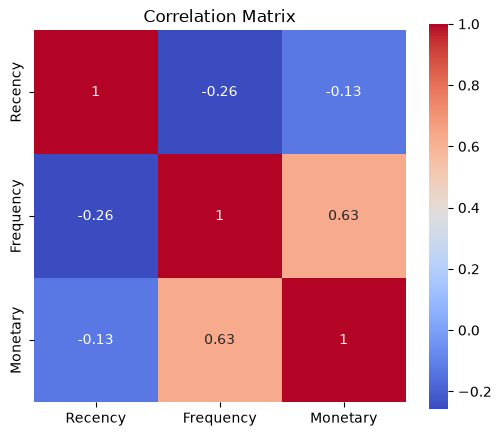

In [26]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rfm[['Recency','Frequency','Monetary']].corr(),
    annot=True,
    cmap='coolwarm',
    square=True
)

plt.title('Correlation Matrix')

plt.show()

### Key Findings

- Identify positive and negative relationships between RFM variables.

### Business Recommendation

Use correlated metrics together when designing future customer analytics models.

# Visualization 8 - Spending Distribution

## Business Question

How does customer spending vary within each segment?

## Why is this important?

Average values alone cannot explain customer behavior. Boxplots reveal variability, spread, and potential outliers within each segment.

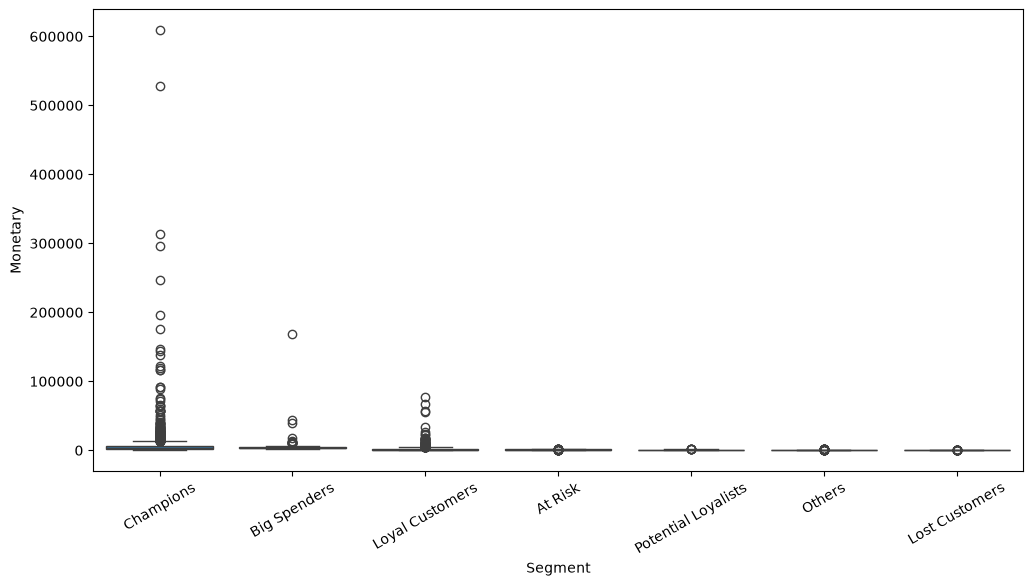

In [27]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=rfm,
    x='Segment',
    y='Monetary'
)

plt.xticks(rotation=30)

plt.show()

### Key Findings

- Compare spending consistency.
- Detect high-value outliers.
- Understand customer variability.

### Business Recommendation

Design personalized strategies for segments with high spending variability while maintaining loyalty programs for consistently valuable customers.

# Business Recommendations

Based on the RFM analysis, the following actions are recommended:

- Reward Champions through exclusive loyalty programs.
- Retain Loyal Customers with personalized offers and membership benefits.
- Encourage Potential Loyalists to become repeat customers through targeted promotions.
- Increase repeat purchases from Big Spenders using premium services.
- Re-engage At Risk customers using personalized email campaigns and limited-time discounts.
- Test win-back campaigns for Lost Customers before allocating significant marketing budgets.

# Project Limitations

Although RFM analysis provides valuable customer insights, the project has some limitations.

- Customer demographics were unavailable.
- Product categories were not analyzed.
- Seasonal purchasing behavior was not considered.
- Marketing campaign history was unavailable.
- Customer Lifetime Value (CLV) was not included.
- Segmentation is rule-based rather than machine-learning driven.

# Future Improvements

This analysis can be extended by incorporating more advanced analytical techniques.

Possible improvements include:

- Customer Lifetime Value (CLV) prediction
- Customer churn prediction
- K-Means clustering
- Product recommendation systems
- Cohort analysis
- Marketing campaign effectiveness analysis
- Interactive Power BI dashboard

# Conclusion

This project successfully segmented customers using the RFM framework by analyzing Recency, Frequency, and Monetary behavior.

The analysis identified valuable customer groups such as Champions, Loyal Customers, and Big Spenders while highlighting At Risk and Lost Customers who require targeted retention strategies.

The insights generated can support personalized marketing campaigns, improve customer retention, and optimize business decision-making through data-driven segmentation.